# Solutions for Chapter 3 Assigned Problems

## Homework 2 Spring 2026
- Wed Jan 21 and Friday Jan 23, we covered Sec 3.1 - Simple linear Regression
  - 3.7.8 (a)(i,ii,iii, modified iv below) and (b)
    - *Modified version of a.iv:* 
      - What are the predicted values for the inputs? 
      - Compute the RSS and MSE using these predicted values.  
  - 3.7.13 
    - Warning for part (b), `np.random.normal` takes standard deviation as input for `scale`, not variance.
  - A note on code. The book's use of the `statsmodels` package is slightly different from the examples provided in the Jupyter notebooks in class. In particular, in the book's lab examples and in the homework statement they implicitly use

    ```python
    import statsmodels.api as sm
    ```

    while we use

    ```python
    import statsmodels.formula.api as smf
    ```

    This results in slight differences in code, in particular whether the function call you use is `OLS` or `ols`. You may use whichever works for you, the answers should be the same.

- Mon Jan 26, we cover Sec 3.2 - Multiple Linear Regression
  - 3.7.1
  - (*Modified version of 3.7.9*): Using the `Auto` data set, we will predict $Y = \texttt{mpg}$ using all other variables except name and origin. 
    - Generate the correlation matrix between all variables. Are there any pairs that are particularly highly correlated?
    - Using `statsmodel`, create a linear model predicting `mpg` from all other variables except `name` and `origin`.
    - Is there a relationship between the predictors and the response? Justify your answer.
    - Which predictors appear to have a statistically significant relationship to the response?
    - What does the coefficient for the year variable suggest?



### Grading distribution 

You should be able to break down the innards however you want. 

- 3.7.8 - 21 points 
- 3.7.13 - 38 points 
- 3.7.1 - 6 points
- 3.7.9ish - 11 points

In [2]:
# As always, we start with our favorite standard imports. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression

&#9989; **<font color=red>Q 3.7.8 (21 points):</font>** This question involves the use of simple linear regression on the `Auto` data set.


In [69]:
# Load data 
# First, we're going to do all the data loading and cleanup we figured out last time.
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/d75c3811a83a66f8c261e5b599ef9e44/Auto.csv"
auto = pd.read_csv(url)
auto = auto.replace('?', np.nan)
auto = auto.dropna()
auto.horsepower = auto.horsepower.astype('int')
auto.shape

(392, 9)

&#9989; **<font color=red>Q 3.7.8 (a) (5 points):</font>**(i,ii,iii)

- (a) Use the sm.OLS() function to perform a simple linear regression with mpg as the response and horsepower as the predictor. Use the summary() function to print the results. 

In [23]:
###YOUR sm.OLS() CODE HERE### (5 points)
###Correct 5 points
###mininal error 4 points
###attemped with error 3 points
###Mininal attemped 1point
###Empty 0 point
est = smf.ols('mpg ~ horsepower', auto).fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Sun, 01 Feb 2026   Prob (F-statistic):           7.03e-81
Time:                        14:22:23   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.9359      0.717     55.660      0.000      38.525      41.347
horsepower    -0.1578      0.006    -24.489      0.000      -0.171      -0.145
==============================================================================
Omnibus:                       16.432   Durbin-Watson:                   0.920
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               17.305
Skew:                           0.492   Prob(JB):                     0.000175
Kurtosis:                       3.299   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

&#9989; **<font color=red>Q 3.7.8 (a)(i,ii,iii) (6 points):</font>**
Comment on the **(a)** output. For example:

    - i. Is there a relationship between the predictor and the response?
    - ii. How strong is the relationship between the predictor and the response?
    - iii. Is the relationship between the predictor and the response positive or negative?

###ANSWER###
- (i/ii) (4 points, each one is 2 points) The p-val for the F-statistic is very slow, so very confident in relationship.
- (iii) (2 points, attempt with errors 1 point) relationship is negative because coefficient of horsepower is negative.

&#9989; **<font color=red>Q 3.7.8 (a) (7 points):</font>**(modified iv below)
- What are the predicted values for the inputs? 
- Compute the RSS and MSE using these predicted values. 


In [71]:
###ANSWER####
y_hat = est.predict(auto.horsepower) ### 3 points
#print(f"y_hat:{y_hat}")
residuals = auto.mpg - y_hat
RSS = (residuals**2).sum() ### 2 points
print(f"RSS: {RSS}")

MSE = RSS / auto.shape[0] #### 2 points
print(f"MSE: {MSE}")

RSS: 9385.915871932417
MSE: 23.943662938603104


&#9989; **<font color=red>Q 3.7.8 (b) (3points):** 
- (b) Plot the response and the predictor in a new set of axes ax. Use the ax.axline() method or the abline() function defined in the lab to display the least squares regression line.


Text(0.5, 1.0, 'MPG vs Horsepower with Least Squares Regression Line')

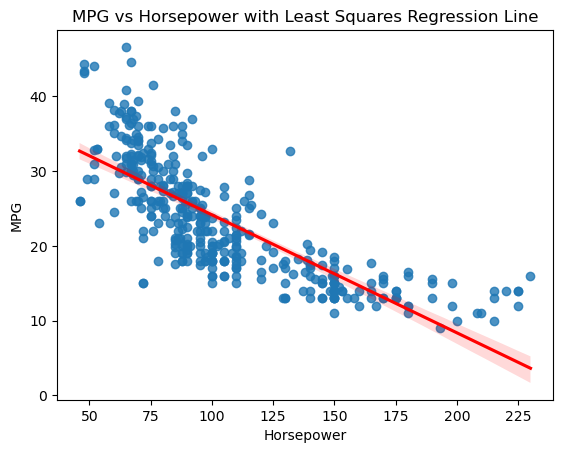

In [25]:
####ANSWER####
# This is way easier, but i'm fine with it if they understand enough to do it instead.
sns.regplot(x = auto.horsepower, y = auto.mpg,  line_kws={'color':'r'}) #### 2 points

plt.xlabel("Horsepower")####1 point
plt.ylabel("MPG")
plt.title("MPG vs Horsepower with Least Squares Regression Line")

#### &#9989;&nbsp; **Question 3.7.8 Documenting Your Solution Pathway (3 points)**

**Answer the following questions in detail:**
1. Indicate which portions of Question 3.7.8 you answered with prior knowledge, and also indicate which portions of Question 3.7.8 you answered with the help of outside sources (e.g. generative AI, past assignments, Stack Overflow, Google, etc.) to help you? (1 point)
2. **For the parts were you DID use external resources**, document what sources you used and how they informed your approach.  If you used generative AI, be sure to include the most important *prompts and outputs*. **For the parts where you DID NOT use external resources**, what prior knowledge did you recall to solve the problem? (2 points)

In [83]:
###YOUR ANSWER HERE (You can use markdown)###

# 1.

# 2.

&#9989; **<font color=red> 3.7.13 (a) (2 points):**

In this exercise you will create some simulated data and will fit simple linear regression models to it. Make sure to use the default random number generator with seed set to 1 prior to starting part (a) to ensure consistent results.


- (a) Using the normal() method of your random number generator, create a vector, x, containing 100 observations drawn from a $N(0, 1)$ distribution. This represents a feature, $X$.


(array([ 3.,  1.,  6., 17., 19., 20., 14., 12.,  5.,  3.]),
 array([-2.3015387 , -1.85282729, -1.40411588, -0.95540447, -0.50669306,
        -0.05798165,  0.39072977,  0.83944118,  1.28815259,  1.736864  ,
         2.18557541]),
 <BarContainer object of 10 artists>)

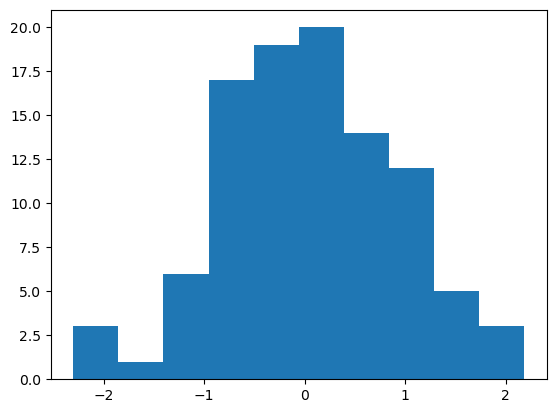

In [85]:
###ANSWER### 2 points
### Attempt with error 1 point
np.random.seed(1)
X = np.random.normal(size=100)
plt.hist(X)

&#9989; **<font color=red> 3.7.13 (b) (2 points):**
Using the normal() method, create a vector, eps, containing 100 observations drawn from a N(0, 0.25) distribution—a normal distribution with mean zero and variance 0.25.


In [86]:
###ANSWER### 2 points
###Attempt with error 1 point
# Warning! numpy wants the standard deviation, so we need to take the square root of the variance.
eps = np.random.normal(0, np.sqrt( 0.25), size=100)



&#9989; **<font color=red> 3.7.13 (c) (3points):** Using x and eps, generate a vector y according to the model

$$
Y = −1 + 0.5X + \varepsilon .
$$


What is the length of the vector $y$? What are the values of $\beta_0$  and $\beta_1$ in this linear model?


In [87]:
####ANSWER#### 3 points
###Each answer is 1 point
# Here beta0 is -1, beta1 is 0.5. The length should be 100 like the input vector X. 
Y = -1 + 0.5 * X + eps


&#9989; **<font color=red> 3.7.13 (d) (2 points):** Create a scatterplot displaying the relationship between x and y. Comment on what you observe.


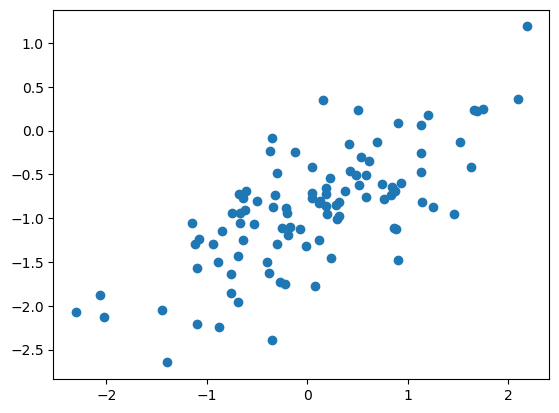

In [88]:
###ANSWER### 2 points
###Attempt with error 1 point
plt.scatter(X, Y)

&#9989; **<font color=red> 3.7.13 (e) (4 points):** Fit a least squares linear model to predict $y$ using $x$. Comment on the model obtained. How do $\hat\beta_0$ and $\hat\beta_1$ compare to $\beta_0$ and $\beta_1$?


In [89]:
####ANSWER####
reg = LinearRegression().fit(X.reshape(-1, 1), Y) ###2 points
print(f"beta1: {np.round(reg.coef_[0],3)}")### 1 point
print(f"beta0: {np.round(reg.intercept_,3)}")### 1 point
# Note they should be close to 0.5 and -1

beta1: 0.548
beta0: -0.926


&#9989; **<font color=red> 3.7.13 (f) (5 points):**
Display the least squares line on the scatterplot obtained in (d). Draw the population regression line on the plot, in a different color. Use the legend() method of the axes to create an appropriate legend.


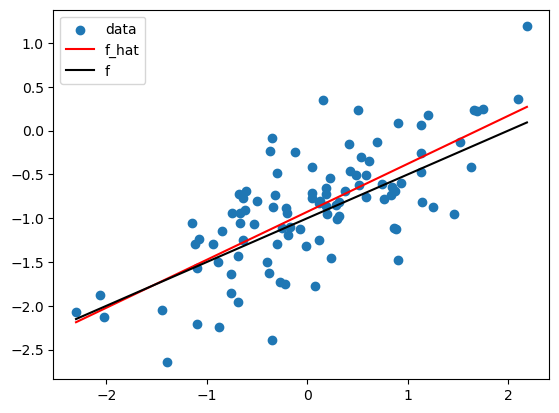

In [90]:
###ANSWER###
t = np.linspace(np.min(X), np.max(X), 100)
f_hat = reg.predict(t.reshape(-1, 1)) ### 1 point
f = -1 + 0.5 * t
plt.scatter(X, Y, label = 'data') ### 1 point
plt.plot(t, f_hat, color='red', label = 'f_hat')#1 point
plt.plot(t, f, color='black', label = 'f') # 1 point
plt.legend() ### 1 point

# They didn't ask for f but I find it helpful


&#9989; **<font color=red> 3.7.13 (g) (5 points):** Now fit a polynomial regression model that predicts y using x and $x^2$ . Is there evidence that the quadratic term improves the model fit? Explain your answer.



In [94]:
###ANSWER###
X_lin = X.reshape(-1, 1)
X_quad = np.column_stack([X, X**2]) #### 1 point

# Linear model
reg_lin = LinearRegression().fit(X_lin, Y) ### 1 point

# Quadratic model
reg_quad = LinearRegression().fit(X_quad, Y)####  1 point

print("Linear R^2:", reg_lin.score(X_lin, Y)) ## 1 point
print("Quadratic R^2:", reg_quad.score(X_quad, Y))

### The increas in R^2 is very small from linear regression to quadratic regression, it suggests no meaningful improvement. ## 1 point

Linear R^2: 0.5218387119375147
Quadratic R^2: 0.5220007118611887


&#9989; **<font color=red> 3.7.13 (h) (4 points):** Repeat (a)–(f) after modifying the data generation process in such a way that there is less noise in the data. The model (3.39) (Equation in 3.7.13 (c)) should remain the same. You can do this by decreasing the variance of the normal distribution used to generate the error term $\varepsilon$ in (b). Describe your results.


beta1: 0.482
beta0: -1.006


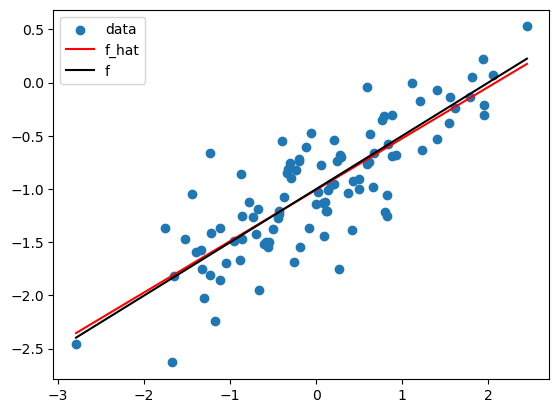

In [95]:
###ANSWER###
var = .1 # Low variance ### 1 point

X = np.random.normal(size=100) ### 2 points
eps = np.random.normal(0, np.sqrt( var), size=100)
Y = -1 + 0.5 * X + eps

reg = LinearRegression().fit(X.reshape(-1, 1), Y)
print(f"beta1: {np.round(reg.coef_[0],3)}")
print(f"beta0: {np.round(reg.intercept_,3)}")

t = np.linspace(np.min(X), np.max(X), 100)
f_hat = reg.predict(t.reshape(-1, 1))
f = -1 + 0.5 * t
plt.scatter(X, Y, label = 'data')
plt.plot(t, f_hat, color='red', label = 'f_hat')
plt.plot(t, f, color='black', label = 'f')
plt.legend()

###the following 1 point
###After decreasing the error variance, the observations concentrate more tightly 
###around the true regression line. The least squares estimates are closer to the true coefficients, and the model fit improves

&#9989; **<font color=red> 3.7.13 (i) (4 points):** Repeat (a)–(f) after modifying the data generation process in such a way that there is more noise in the data. The model (3.39) should remain the same. You can do this by increasing the variance of the normal distribution used to generate the error term " in (b). Describe your results.


beta1: 0.59
beta0: -0.88


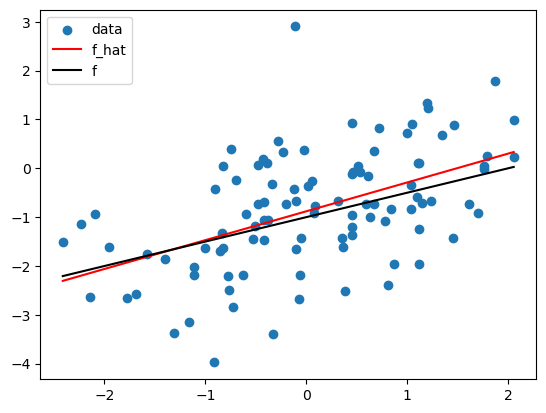

In [96]:
###ANSWER###
var = 1 # High variance ## 1point

X = np.random.normal(size=100) ### 2 points
eps = np.random.normal(0, np.sqrt(var), size=100)
Y = -1 + 0.5 * X + eps

reg = LinearRegression().fit(X.reshape(-1, 1), Y)
print(f"beta1: {np.round(reg.coef_[0],3)}")
print(f"beta0: {np.round(reg.intercept_,3)}")

t = np.linspace(np.min(X), np.max(X), 100)
f_hat = reg.predict(t.reshape(-1, 1))
f = -1 + 0.5 * t
plt.scatter(X, Y, label = 'data')
plt.plot(t, f_hat, color='red', label = 'f_hat')
plt.plot(t, f, color='black', label = 'f')
plt.legend()

### The following 1 point
#### When increase the variance from 0.25 to 1, they should notice that their line doesn't match up as well

&#9989; **<font color=red> 3.7.13 (j) (2 points):** 1)What are the confidence intervals for $\beta_0$ and $\beta_1$ based on the original data set.

In [98]:
###ANSWER### 2 points
### Attempt with error 1 point
var = .25 # Medium variance

X = np.random.normal(size=100)
eps = np.random.normal(0, np.sqrt( var), size=100)
Y = -1 + 0.5 * X + eps

data = pd.DataFrame({'X': X, 'Y': Y})
smf.ols('Y ~ X', data = data).fit().conf_int()

,0,1
Intercept,-1.057985,-0.882320
X,0.329099,0.517878


&#9989; **<font color=red> 3.7.13 (j) (2points):** 2)What are the confidence intervals for $\beta_0$ and $\beta_1$ based on the noisier data set.

In [82]:
###ANSWER### 2 points
### Attempt with error 1 point
var = 1 # High variance

X = np.random.normal(size=100)
eps = np.random.normal(0, np.sqrt( var), size=100)
Y = -1 + 0.5 * X + eps

data = pd.DataFrame({'X': X, 'Y': Y})
smf.ols('Y ~ X', data = data).fit().summary().tables[1]

smf.ols('Y ~ X', data = data).fit().conf_int()

,0,1
Intercept,-1.205031,-0.815980
X,0.138100,0.555713


&#9989; **<font color=red> 3.7.13 (j) (2points):** 3)What are the confidence intervals for $\beta_0$ and $\beta_1$ based on the less noisy data set? Comment on your results.

In [52]:
###ANSWER### 2 points
### Attempt with error 1 point
var = .1 # Low variance

X = np.random.normal(size=100)
eps = np.random.normal(0, np.sqrt( var), size=100)
Y = -1 + 0.5 * X + eps

data = pd.DataFrame({'X': X, 'Y': Y})
smf.ols('Y ~ X', data = data).fit().conf_int()


,0,1
Intercept,-1.088367,-0.96411
X,0.378503,0.51326


&#9989; **<font color=red> 3.7.13 (j) (1 point):** 4)Please comment on your above three different confidence interval results.

###ANSWER### *Should notice the confidence intervals are generally smaller for smaller variance*

&#9989; **<font color=red> 3.7.1 (6 points):**

Describe the null hypotheses to which the p-values given in Table 3.4 correspond. Explain what conclusions you can draw based on these p-values. Your explanation should be phrased in terms of `sales`, `TV`, `radio`, and `newspaper`, rather than in terms of the coefficients of the linear model.

![](../../Lectures/Figures/Table3-4.png)

###ANSWER## (Correct 3 points, attempt with error 2 points, minimal attempt 1 point)

- Null hypothesis for each is that the coefficient is 0. So in this case, we have that TV and radio have a high chance of being 0, but newspaper doesn't reject the null.
- Note that this is different than saying they have a relationship. We can fit the model to just newspaper and have a relationship between the variables but the fact that newspaper and (whichever otherone i forget but said it in class) means in that setting it would be a low p-value.  

#### &#9989;&nbsp; **Question 3.7.1 Documenting Your Solution Pathway (3 points)**

**Answer the following questions in detail:**
1. Indicate which portions of question 3.7.1 you answered with prior knowledge, and also indicate which portions of question 3.7.1 you answered with the help of outside sources (e.g. generative AI, past assignments, Stack Overflow, Google, etc.) to help you? (1 point)
2. **For the parts were you DID use external resources**, document what sources you used and how they informed your approach.  If you used generative AI, be sure to include the most important *prompts and outputs*. **For the parts where you DID NOT use external resources**, what prior knowledge did you recall to solve the problem? (2 points)

In [84]:
###YOUR ANSWER HERE (You can use markdown)###

### 1.


### 2.

&#9989; **<font color=red> Modified version of 3.7.9 (11 points):**  Using the `Auto` data set, we will predict $Y = \texttt{mpg}$ using all other variables except name. 


In [56]:
# Load data 
# First, we're going to do all the data loading and cleanup we figured out last time.
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/d75c3811a83a66f8c261e5b599ef9e44/Auto.csv"
auto = pd.read_csv(url)
auto = auto.replace('?', np.nan)
auto = auto.dropna()
auto.horsepower = auto.horsepower.astype('int')
auto.shape

(392, 9)

&#9989; **<font color=red> Modified version of 3.7.9 (i) (3 points):**  
    - Generate the correlation matrix between all variables. Are there any pairs that are particularly highly correlated?

<Axes: >

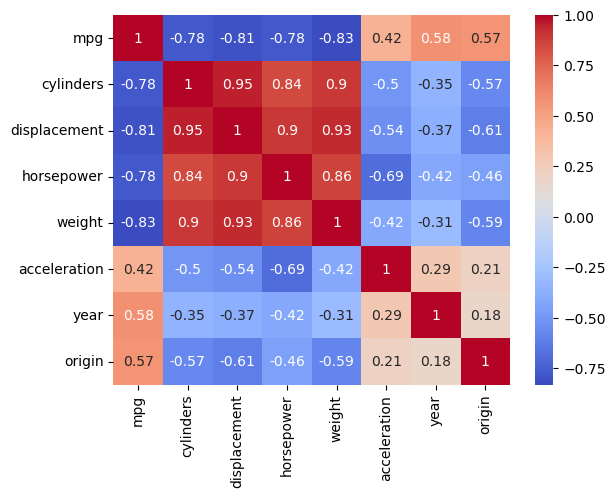

In [99]:
###ANSWER###
#C = auto.corr()
C = auto.corr(numeric_only=True) ### 2 points
sns.heatmap(C, annot=True, cmap = 'coolwarm')

### the following is 1 point
# MPG highly neg correlated with cylinders, displacement, horsepower, weight
# cylinders, displacement, horsepower, weight highly pos correlated with each other


&#9989; **<font color=red> Modified version of 3.7.9 (ii) (2 points):** 
    - Using `statsmodel`, create a linear model predicting `mpg` from all other variables except `name`.
    

In [100]:
###ANSWER### 2 points
### Attempt with error 1 point
smf.ols('mpg ~ cylinders + displacement + horsepower + weight + acceleration + year', data = auto).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     272.2
Date:                Mon, 02 Feb 2026   Prob (F-statistic):          3.79e-135
Time:                        09:46:06   Log-Likelihood:                -1036.5
No. Observations:                 392   AIC:                             2087.
Df Residuals:                     385   BIC:                             2115.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -14.5353      4.764     -3.051      0.002     -23.902      -5.169
cylinders       -0.3299      0.332     -0.993      0.321      -0.983       0.323
displacement     0.0077      0.007      1.044      0.297      -0.007       0.022
horsepower      -0.0004      0.014     -0.028      0.977      -0.028       0.027
weight          -0.0068      0.001    -10.141      0.000      -0.008      -0.005
acceleration     0.0853      0.102      0.836      0.404      -0.115       0.286
year             0.7534      0.053     14.318      0.000       0.650       0.857
==============================================================================
Omnibus:                       37.865   Durbin-Watson:                   1.232
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               60.248
Skew:                           0.630   Prob(JB):                     8.26e-14
Kurtosis:                       4.449   Cond. No.                     8.53e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.53e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

&#9989; **<font color=red> Modified version of 3.7.9 (iii) (1 point):**  
- Is there a relationship between the predictors and the response? Justify your answer.
    

###ANSWER### Yes there is a relationship because the F-statistic p-value is very low. 

&#9989; **<font color=red> Modified version of 3.7.9 (iv) (1 point):**  
    - Which predictors appear to have a statistically significant relationship to the response?
    

###ANSWER### Looks like weight and year are the strongest, likely because weight is compensating for the rest of the correlated group. 

&#9989; **<font color=red> Modified version of 3.7.9 (iii) (1 point):**  
    - What does the coefficient for the year variable suggest?

###ANSWER### - Coefficient for year is positive, implying that the model says that increasing years result in improved MPG.

#### &#9989;&nbsp; **Question 3.7.9 Documenting Your Solution Pathway (3 points)**

**Answer the following questions in detail:**
1. Indicate which portions of Question 3.7.9 you answered with prior knowledge, and also indicate which portions of Question 3.7.9 you answered with the help of outside sources (e.g. generative AI, past assignments, Stack Overflow, Google, etc.) to help you? (1 point)
2. **For the parts were you DID use external resources**, document what sources you used and how they informed your approach.  If you used generative AI, be sure to include the most important *prompts and outputs*. **For the parts where you DID NOT use external resources**, what prior knowledge did you recall to solve the problem? (2 points)

In [101]:
### YOUR ANSWER HERE (You can use markdown)###
#1.

#2.